<a href="https://colab.research.google.com/github/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/blob/main/Praktikum4/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [6]:
DATA_PATH = "https://raw.githubusercontent.com/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/main/Praktikum4/Advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

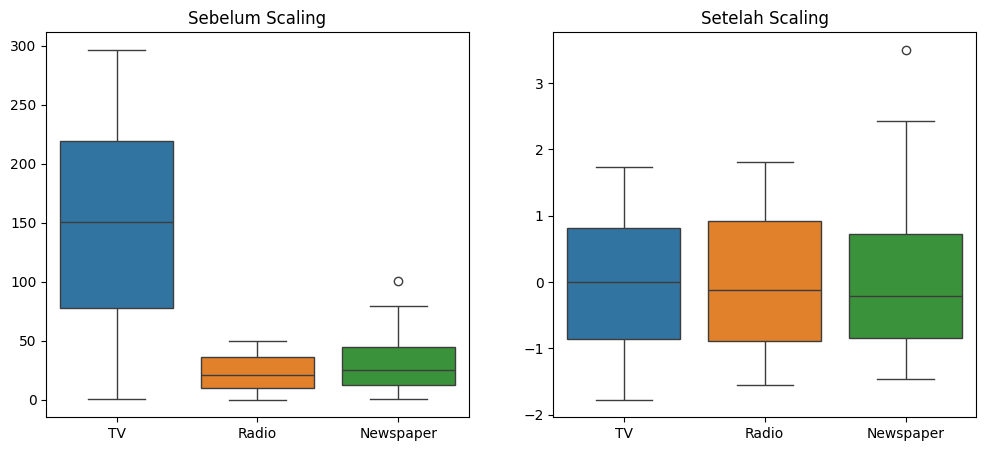

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=X_train[['TV','Radio','Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV','Radio', 'Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

In [10]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6442982086509947
RMSE Test : 1.788576100865966
Coefficients: [0.03809349 3.76325651 2.79313507 0.0617462 ]


In [11]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6445572594930091
RMSE Test : 1.7942139337233356
Coefficients: [0.03798751 3.74076155 2.77414819 0.06909508]


In [12]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)


Lasso Regression (alpha=0.1)
RMSE Train: 1.6512929556878617
RMSE Test : 1.791333811555155
Coefficients: [0.         3.66920574 2.71914667 0.        ]


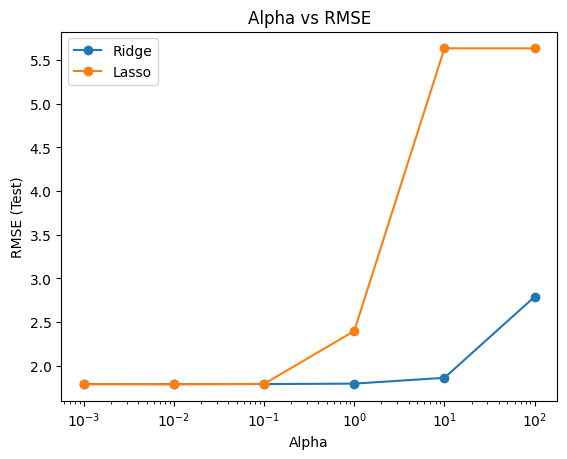

In [13]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

In [14]:
# Tugas 3a,  5 nilai lambda baru
alphas_baru = [0.0001, 0.005, 0.05, 0.5, 5]

print("=== Eksperimen 5 Nilai Lambda Baru ===")
print(f"{'Alpha':<10} {'Ridge RMSE Train':<20} {'Ridge RMSE Test':<20} {'Lasso RMSE Train':<20} {'Lasso RMSE Test'}")
print("-" * 90)

for a in alphas_baru:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    r_train = np.sqrt(mean_squared_error(y_train, r.predict(X_train_scaled)))
    r_test  = np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled)))
    l_train = np.sqrt(mean_squared_error(y_train, l.predict(X_train_scaled)))
    l_test  = np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled)))

    print(f"{a:<10} {r_train:<20.6f} {r_test:<20.6f} {l_train:<20.6f} {l_test:.6f}")

=== Eksperimen 5 Nilai Lambda Baru ===
Alpha      Ridge RMSE Train     Ridge RMSE Test      Lasso RMSE Train     Lasso RMSE Test
------------------------------------------------------------------------------------------
0.0001     1.644298             1.788577             1.644298             1.788553
0.005      1.644298             1.788603             1.644326             1.787416
0.05       1.644299             1.788848             1.646506             1.783115
0.5        1.644363             1.791343             1.783881             1.978445
5          1.650431             1.820581             5.092764             5.631496


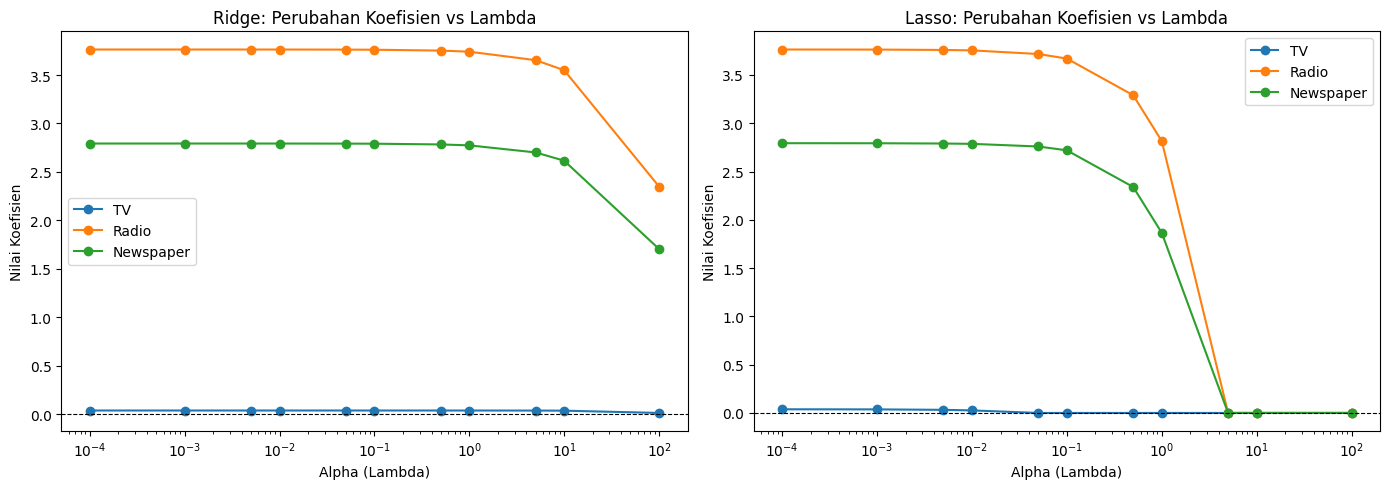

In [16]:
# Tugas 3b - Grafik perubahan koefisien terhadap lambda
alphas_coef = [0.0001, 0.005, 0.05, 0.5, 5, 0.001, 0.01, 0.1, 1, 10, 100]
alphas_coef = sorted(alphas_coef)
features = ['TV', 'Radio', 'Newspaper']

ridge_coefs = []
lasso_coefs = []

for a in alphas_coef:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(r.coef_)
    lasso_coefs.append(l.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Ridge
for i, feat in enumerate(features):
    axes[0].plot(alphas_coef, ridge_coefs[:, i], marker='o', label=feat)
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha (Lambda)")
axes[0].set_ylabel("Nilai Koefisien")
axes[0].set_title("Ridge: Perubahan Koefisien vs Lambda")
axes[0].legend()
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)

# Plot Lasso
for i, feat in enumerate(features):
    axes[1].plot(alphas_coef, lasso_coefs[:, i], marker='o', label=feat)
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha (Lambda)")
axes[1].set_ylabel("Nilai Koefisien")
axes[1].set_title("Lasso: Perubahan Koefisien vs Lambda")
axes[1].legend()
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()